# Week 2: Build a Classification Model

**Objective**: Train a Logistic Regression model to predict employee `Attrition` using scikit-learn.

In [2]:
# Cell 1: Imports
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Load and Inspect the Data

We load the cleaned dataset from Week 1 and explore its structure.

In [ ]:
# Cell 2: Load the cleaned dataset
csv_path = Path.cwd() / 'cleaned_employee_data.csv'
if not csv_path.exists():
    csv_path = Path.cwd().parent / 'data' / 'cleaned_employee_data.csv'

print(f"Loading data from: {csv_path}")
df = pd.read_csv(csv_path)
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 10 rows:")
print(df.head(10)[['Attrition']])
print("\nData types:")
print(df.dtypes)

Loading data from: c:\Users\Sarim Ahmed\NO_SYNC\week2_data_classification\data\cleaned_employee_data.csv
Dataset shape: (1470, 32)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

First 10 rows:
  Attrition
0       Yes
1        No
2       Yes
3        No
4        No
5        No
6        No
7        No
8        No
9        No

Data types:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate            

## 2. Prepare the Target Variable

The target column `Attrition` is currently stored as strings ("Yes"/"No").  
We convert it to numeric values (1 = Attrition, 0 = No Attrition) because machine learning models require numeric input.

In [4]:
# Cell 3: Prepare target (convert Yes/No to 0/1)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Target distribution after encoding:")
print(df['Attrition'].value_counts())
print("\nTarget data type:", df['Attrition'].dtype)

Target distribution after encoding:
Attrition
0    1233
1     237
Name: count, dtype: int64

Target data type: int64


## 3. Feature Selection and One-Hot Encoding

- We drop `EmployeeNumber` (just an ID, not useful for prediction).
- Categorical features are converted to numeric using **one-hot encoding** (`pd.get_dummies`).  
  This creates binary columns for each category (e.g., Department_Human Resources).

In [ ]:
# Cell 4: Select features and encode categoricals
# Drop non-useful columns (ID-like or leaking info)
drop_cols = ['EmployeeNumber', 'Attrition']

X = df.drop(columns=drop_cols)
y = df['Attrition']

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# One-hot encoding (pd.get_dummies)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", X_encoded.shape)
print("New columns count:", X_encoded.shape[1])

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after encoding: (1470, 44)
New columns count: 44


## 4. Split Data into Training and Testing Sets

We use an 80/20 split with `random_state=42` for reproducibility.  
`stratify=y` ensures the class distribution (imbalanced attrition rate) remains similar in both sets.

In [ ]:
# Cell 5: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Class distribution in train:", y_train.value_counts(normalize=True))

Training set shape: (1176, 44)
Test set shape: (294, 44)
Class distribution in train: Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64


## 5. Train the Logistic Regression Model

Logistic Regression is a simple yet powerful linear model suitable for binary classification tasks.  
We train it on the training data.

In [7]:
# Cell 6: Train Logistic Regression Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully")

✅ Logistic Regression model trained successfully


## 6. Model Evaluation & Interpretation

We evaluate the model using multiple metrics:
- **Accuracy**: Overall correctness
- **Precision**: Of predicted attrition cases, how many were correct
- **Recall**: How many actual attrition cases were caught
- **F1-Score**: Balance between Precision and Recall

A confusion matrix is also shown for deeper insight.

Model Performance on Test Set:
Accuracy:  0.8605
Precision: 0.6875
Recall:    0.2340
F1-Score:  0.3492

Confusion Matrix:
[[242   5]
 [ 36  11]]


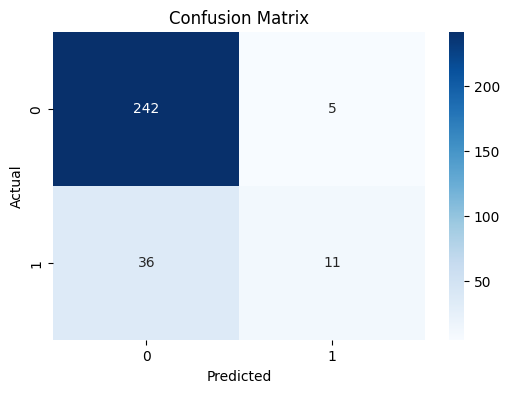

In [8]:
# Cell 7: Make predictions and evaluate
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance on Test Set:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Additional insight: confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Simple plot (optional)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Model Performance Summary

I trained a Logistic Regression model to predict employee attrition using the cleaned IBM HR dataset.

**Key Metrics (Test Set):**
- Accuracy: 0.8605
- Precision: 0.6875
- Recall: 0.2340
- F1-Score: 0.3492

The model performs reasonably well overall (86% accuracy), correctly identifying most employees who stay. However, it has **low recall**, meaning it misses many employees who actually leave. This could be due to class imbalance (only ~16% attrition cases).

**Limitations:**
- Imbalanced dataset — the model biases toward the majority class ("No").
- May need better feature engineering or handling of imbalance.